# EDA: German Electricity Consumption

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/raw/opsd_germany_daily.csv', index_col=0, parse_dates=True)
df.head()

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN
2006-01-04,1457.217,NaN,NaN,NaN
2006-01-05,1477.131,NaN,NaN,NaN


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4383, 4)
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object
Consumption       0
Wind           1463
Solar          2195
Wind+Solar     2196
dtype: int64


In [3]:
print(f"Date range: {df.index.min()} to {df.index.max()}")
print()
print(df['Consumption'].describe())

Date range: 2006-01-01 00:00:00 to 2017-12-31 00:00:00

count    4383.000000
mean     1338.675836
std       165.775710
min       842.395000
25%      1217.859000
50%      1367.123000
75%      1457.761000
max      1709.568000
Name: Consumption, dtype: float64


## Consumption over time

Strong seasonal pattern as expected : Germany runs significantly higher consumption in winter. 
The weekly rhythm is also visible. 
Some isolated sharp drops are probably public holidays (Christmas etc).

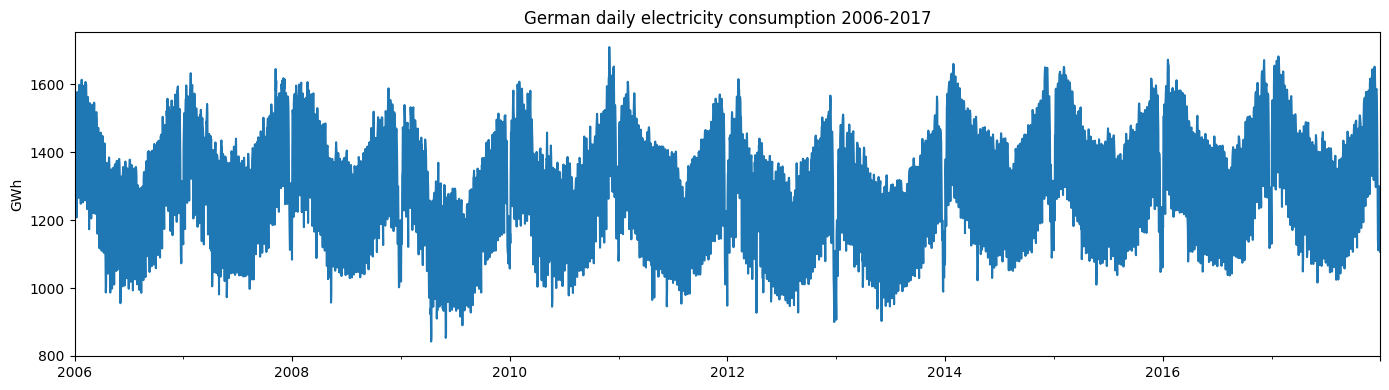

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
df['Consumption'].plot(ax=ax)
ax.set_title('German daily electricity consumption 2006-2017')
ax.set_ylabel('GWh')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Weekly pattern

Weekdays are pretty flat around 1400 GWh, then it drops off on Saturday and Sunday. 
Sunday is the lowest. 

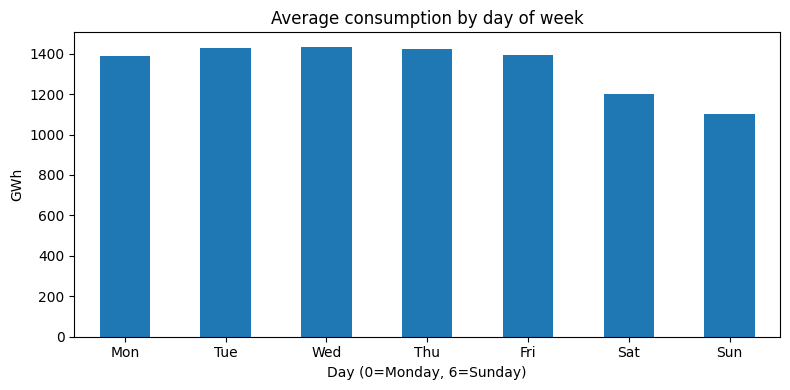

In [5]:
df['dayofweek'] = df.index.dayofweek

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('dayofweek')['Consumption'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average consumption by day of week')
ax.set_xlabel('Day (0=Monday, 6=Sunday)')
ax.set_ylabel('GWh')
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.tight_layout()
plt.show()

## Monthly pattern

Winter months (Jan/Feb) are highest, summer (Aug) lowest, but only about 200 GWh difference. December is lower than Jan/Feb, probably holiday shutdowns.

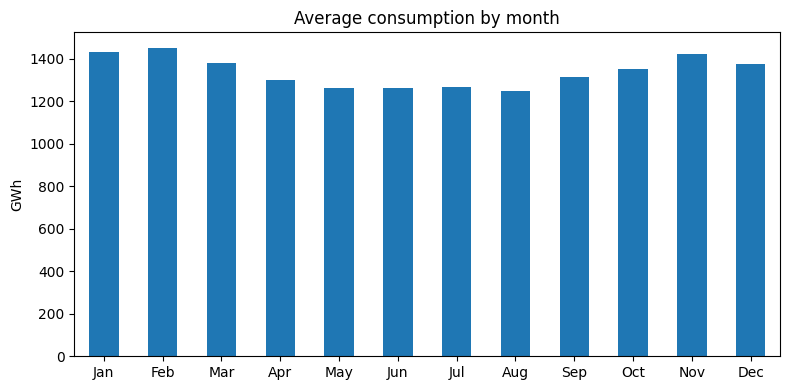

In [6]:
df['month'] = df.index.month

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('month')['Consumption'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average consumption by month')
ax.set_xlabel('')
ax.set_ylabel('GWh')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

## Feature Engineering

Adding time-based and lag features for the forecasting models.

In [17]:
import sys
sys.path.append('../src')
from preprocess import add_features, split_data, fetch_temperature

print("Fetching temperature data...")
temperature = fetch_temperature('2006-01-01', '2017-12-31')
data = add_features(df, temperature)

print(data.shape)
data.head()

Fetching temperature data...
(2187, 12)


,Consumption,Wind,Solar,Wind+Solar,dayofweek,month,temperature,is_weekend,is_holiday,lag_1,lag_7,rolling_7
Date,,,,,,,,,,,,
2012-01-01,948.128,227.465,6.587,234.052,6,1,6.9,1,1,1077.625,1011.431,1135.718714
2012-01-02,1269.581,207.327,6.574,213.901,0,1,9.5,0,0,948.128,1010.596,1126.675429
2012-01-03,1334.745,473.468,24.679,498.147,1,1,5.9,0,0,1269.581,1206.980,1163.673286
2012-01-04,1347.136,499.804,14.681,514.485,2,1,5.4,0,0,1334.745,1216.645,1181.925429
2012-01-05,1376.658,523.851,5.071,528.922,3,1,4.7,0,0,1347.136,1226.888,1200.567000


In [18]:
train, test, features, target = split_data(data)

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Train: {train.shape[0]} rows ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {test.shape[0]} rows ({test.index.min().date()} to {test.index.max().date()})")
print(f"Features: {features}")

Train: 1822 rows (2012-01-01 to 2016-12-31)
Test:  365 rows (2017-01-01 to 2017-12-31)
Features: ['dayofweek', 'month', 'is_weekend', 'is_holiday', 'temperature', 'lag_1', 'lag_7', 'rolling_7']


## Baseline Model: Day-of-week weighted average 
Predict consumption as weighted average of last n same-weekdays.
Recent weeks get higher weight.

In [19]:
import time

def dow_average_baseline(train, test, n_weeks=5, decay=0.85):
    predictions = []
    all_data = pd.concat([train, test])
    
    for date, row in test.iterrows():
        dow = date.dayofweek
        month = date.month
        same_dow_month = all_data[
            (all_data.index.dayofweek == dow) &
            (all_data.index.month == month) &
            (all_data.index < date)
        ]
        last_n = same_dow_month.iloc[-n_weeks:]
        weights = np.array([decay ** i for i in range(len(last_n)-1, -1, -1)])
        weights = weights / weights.sum()
        pred = np.average(last_n['Consumption'].values, weights=weights)
        predictions.append(pred)
    
    return np.array(predictions)

t0 = time.time()
dow_pred = dow_average_baseline(train, test)
baseline_time = time.time() - t0

mae_dow = mean_absolute_error(y_test, dow_pred)
rmse_dow = np.sqrt(mean_squared_error(y_test, dow_pred))

print(f"Day-of-week baseline — MAE: {mae_dow:.2f}, RMSE: {rmse_dow:.2f}, inference: {baseline_time:.3f}s")

Day-of-week baseline — MAE: 47.83, RMSE: 78.15, inference: 0.112s


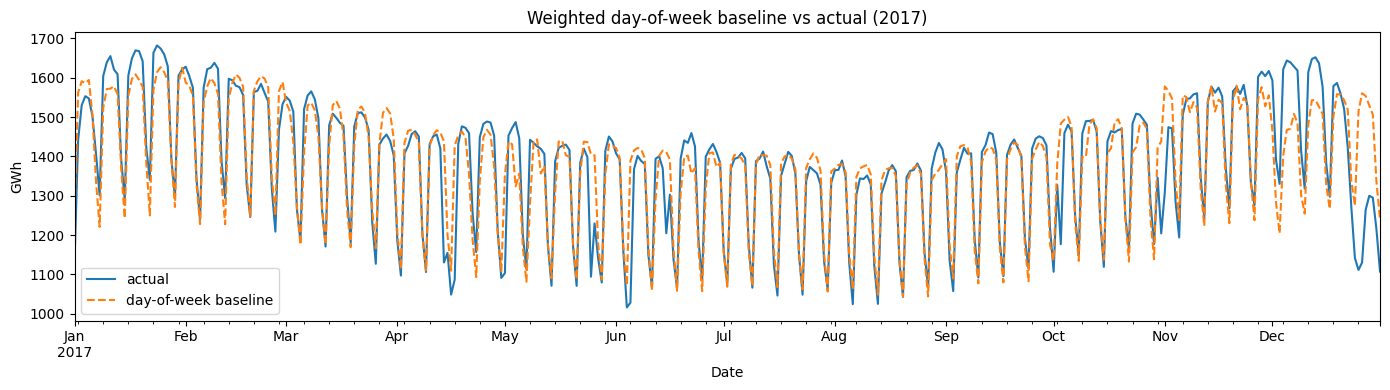

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
pd.Series(dow_pred, index=y_test.index).plot(ax=ax, label='day-of-week baseline', linestyle='--')
ax.set_title('Weighted day-of-week baseline vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

## Model 2: KNN

K-Nearest Neighbours : finds the most similar historical days and averages their consumption.
Similar logic to the baseline but learns from all features together rather than rules.

In [21]:
import time

t0 = time.time()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)
knn_train_time = time.time() - t0

t0 = time.time()
knn_pred = knn.predict(X_test_scaled)
knn_inference_time = time.time() - t0

mae_knn = mean_absolute_error(y_test, knn_pred)
rmse_knn = np.sqrt(mean_squared_error(y_test, knn_pred))

print(f"KNN — MAE: {mae_knn:.2f}, RMSE: {rmse_knn:.2f}, train: {knn_train_time:.3f}s, inference: {knn_inference_time:.3f}s")

KNN — MAE: 24.96, RMSE: 35.36, train: 0.020s, inference: 0.006s


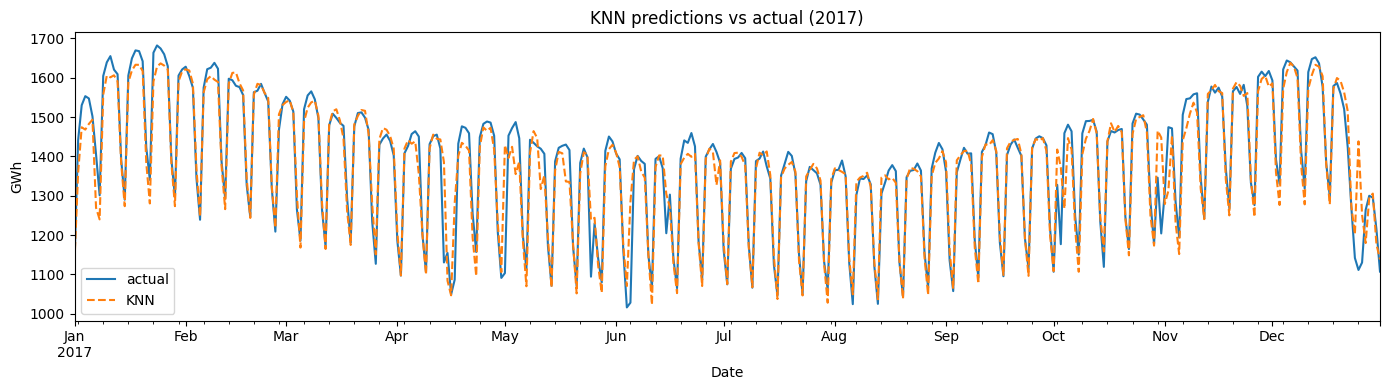

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
pd.Series(knn_pred, index=y_test.index).plot(ax=ax, label='KNN', linestyle='--')
ax.set_title('KNN predictions vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

 ## KNN results

MAE: 29 GWh, RMSE: 51 GWh. 

Clear improvement over the baseline. 

The weekly and seasonal patterns are both captured well. Main weakness is the sharp 
holiday dips which the model can't anticipate without explicit holiday features.

## Model 3: MLP (Neural Network)

Simple feedforward neural network: two hidden layers. 
Should pick up non-linear interactions between features that KNN might miss.


In [23]:
t0 = time.time()
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                   max_iter=2000, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - t0

t0 = time.time()
mlp_pred = mlp.predict(X_test_scaled)
mlp_inference_time = time.time() - t0

mae_mlp = mean_absolute_error(y_test, mlp_pred)
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_pred))

print(f"MLP — MAE: {mae_mlp:.2f}, RMSE: {rmse_mlp:.2f}, train: {mlp_train_time:.3f}s, inference: {mlp_inference_time:.3f}s")

MLP — MAE: 20.15, RMSE: 31.95, train: 1.849s, inference: 0.000s


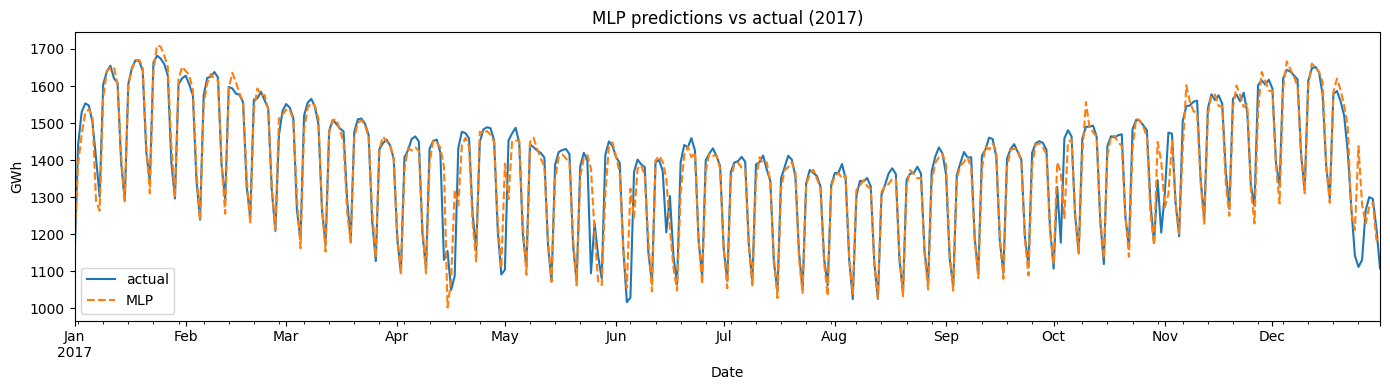

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
pd.Series(mlp_pred, index=y_test.index).plot(ax=ax, label='MLP', linestyle='--')
ax.set_title('MLP predictions vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

## MLP results

MAE: 27 GWh, RMSE: 52 GWh. Marginally better than KNN on MAE but almost identical 
overall. With only 6 features there's not much room for the neural network to find 
additional non-linear patterns beyond what KNN already captures. Both models struggle 
on sharp holiday dips, expected without explicit holiday features.

## Model comparison

                        MAE   RMSE
Day-of-week baseline  47.83  78.15
KNN                   24.96  35.36
MLP                   20.15  31.95


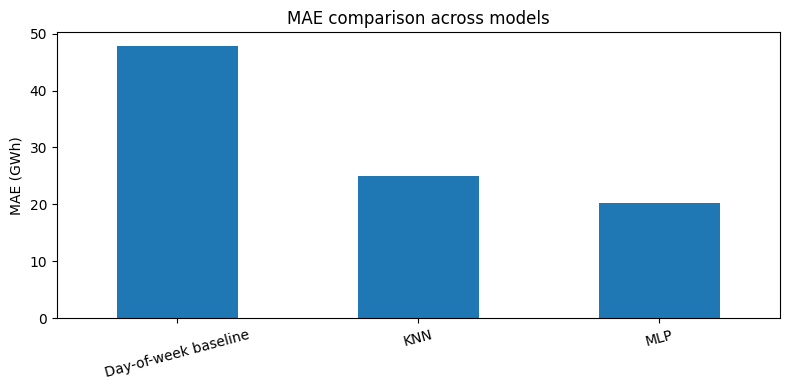

In [25]:
results = {
    'Day-of-week baseline': {'MAE': mae_dow, 'RMSE': rmse_dow},
    'KNN': {'MAE': mae_knn, 'RMSE': rmse_knn},
    'MLP': {'MAE': mae_mlp, 'RMSE': rmse_mlp}
}

results_df = pd.DataFrame(results).T
print(results_df.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
results_df['MAE'].plot(kind='bar', ax=ax)
ax.set_title('MAE comparison across models')
ax.set_ylabel('MAE (GWh)')
ax.set_xticklabels(results_df.index, rotation=15)
plt.tight_layout()
plt.show()

## Conclusion

Tested all three models on 2017 holdout data (365 days), with temperature and 
holiday features added:

| Model | MAE | RMSE | Train time | Inference time |
|-------|-----|------|------------|----------------|
| Day-of-week baseline | 48 GWh | 78 GWh | — | 0.11s |
| KNN | 25 GWh | 35 GWh | 0.02s | 0.006s |
| MLP | 20 GWh | 32 GWh | 1.85s | ~0s |

Adding temperature and holiday features improved KNN from 29 to 25